In [14]:
import sys
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q', '--upgrade', 'ultralytics', 'scipy'], check=True)

    from google.colab import drive
    drive.mount('/content/drive')

    # ── Only line you need to change ─────────────────────────────────────────
    DRIVE_PROJECT_PATH = '/content/drive/MyDrive/CMPE401-Project1'
    # ─────────────────────────────────────────────────────────────────────────

    DRIVE_ROOT = Path(DRIVE_PROJECT_PATH)
    DRIVE_DATA = DRIVE_ROOT / 'Data'

    if not DRIVE_DATA.exists():
        raise FileNotFoundError(
            f'\n\nData folder not found at {DRIVE_DATA}\n'
            'Wait for the Google Drive desktop app to show "up to date", then retry.'
        )

    expected = ['VisDrone2019-DET-train', 'VisDrone2019-DET-val', 'VisDrone2019-DET-test-dev']
    missing  = [d for d in expected if not (DRIVE_DATA / d / 'images').exists()]
    if missing:
        raise FileNotFoundError(f'Missing subfolders not yet synced: {missing}')

    # Write a visdrone.yaml pointing directly to Drive (no copy needed)
    _yaml = f"""path: {DRIVE_DATA}
train: VisDrone2019-DET-train/images
val:   VisDrone2019-DET-val/images
test:  VisDrone2019-DET-test-dev/images
nc: 10
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
"""
    LOCAL_CFG = Path('/content/visdrone.yaml')
    LOCAL_CFG.write_text(_yaml)

    # Model weights and logs go to local SSD (fast writes)
    LOCAL_RUNS_DIR = Path('/content/comparison_runs')
    LOCAL_RUNS_DIR.mkdir(parents=True, exist_ok=True)

    # Metrics cache goes to Drive (survives session restarts)
    DRIVE_CACHE_DIR = DRIVE_ROOT / 'results' / 'comparison'
    DRIVE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

    print('Setup complete.')
    print(f'  Data config : {LOCAL_CFG}')
    print(f'  Training out: {LOCAL_RUNS_DIR}  (local SSD)')
    print(f'  Drive cache : {DRIVE_CACHE_DIR}')

else:
    print('Local mode - no setup needed.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.
  Data config : /content/visdrone.yaml
  Training out: /content/comparison_runs  (local SSD)
  Drive cache : /content/drive/MyDrive/CMPE401-Project1/results/comparison


# Notebook 05  -  Multi-Version YOLO Comparison (Part V)

**Objective:** Compare YOLO11 with at least THREE other YOLO versions on VisDrone under identical training conditions.

## Models Compared

| Model | Version | Params | Key Innovation |
|-------|---------|--------|----------------|
| YOLOv5su | v5 | ~7.2M | Anchor-based, first widely-adopted YOLO |
| YOLOv8s  | v8 | ~11.2M | Anchor-free, strong baseline |
| YOLOv9c  | v9 | ~25.3M | GELAN + PGI |
| YOLOv10s | v10 | ~7.2M | NMS-free (one-to-one head) |
| YOLO11s  | v11 | ~9.4M | Improved backbone + neck |
| YOLO26s  | v26 | ~9.5M | NMS-free, MuSGD optimizer, ProgLoss |

All models are trained for the same number of epochs at 640px on the same VisDrone split.

In [15]:
import sys, os
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Paths set up in the setup cell above
    DATA_CFG      = Path('/content/visdrone.yaml')       # local SSD yaml
    LOCAL_RUNS_DIR = Path('/content/comparison_runs')    # fast local writes
    PROJECT_DIR    = DRIVE_CACHE_DIR                     # Drive: for plots / tables
else:
    ROOT = Path('..').resolve()
    sys.path.insert(0, str(ROOT))
    DATA_CFG       = ROOT / 'configs' / 'visdrone.yaml'
    LOCAL_RUNS_DIR = ROOT / 'results' / 'comparison'
    PROJECT_DIR    = LOCAL_RUNS_DIR
    DRIVE_CACHE_DIR = LOCAL_RUNS_DIR   # same on local — no distinction needed

PROJECT_DIR.mkdir(parents=True, exist_ok=True)

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
from ultralytics import YOLO

sns.set_theme(style='whitegrid')

# Auto-detect best available device and dataloader workers
if torch.cuda.is_available():
    DEVICE  = 0       # CUDA (Colab A100 / T4)
    WORKERS = 4       # A100 Colab has 12 CPU cores; 4 is safe and fast
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE  = 'mps'   # Apple Silicon (local only)
    WORKERS = 0       # MPS requires 0 workers
else:
    DEVICE  = 'cpu'
    WORKERS = 0

# MPS workaround — only runs locally on Apple Silicon, never on Colab
if str(DEVICE) == 'mps':
    from ultralytics.utils.tal import TaskAlignedAssigner
    if not hasattr(TaskAlignedAssigner, '_original_forward'):
        TaskAlignedAssigner._original_forward = TaskAlignedAssigner._forward

    def _tal_forward_mps_safe(self, pd_scores, pd_bboxes, anc_points,
                               gt_labels, gt_bboxes, mask_gt):
        result = TaskAlignedAssigner._original_forward(
            self,
            pd_scores.cpu(), pd_bboxes.cpu(), anc_points.cpu(),
            gt_labels.cpu(), gt_bboxes.cpu(), mask_gt.cpu(),
        )
        return tuple(t.to(pd_scores.device) if isinstance(t, torch.Tensor) else t
                     for t in result)
    TaskAlignedAssigner._forward = _tal_forward_mps_safe

print(f'DATA_CFG:      {DATA_CFG}')
print(f'Training runs: {LOCAL_RUNS_DIR}')
print(f'Results/cache: {PROJECT_DIR}')
print(f'Device:  {DEVICE}  |  Workers: {WORKERS}')
print(f'PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:     {torch.cuda.get_device_name(0)}')


DATA_CFG:      /content/visdrone.yaml
Training runs: /content/comparison_runs
Results/cache: /content/drive/MyDrive/CMPE401-Project1/results/comparison
Device:  cpu  |  Workers: 0
PyTorch: 2.10.0+cpu  |  CUDA: False


## Shared Training Protocol

To ensure a fair comparison, **all models use identical hyperparameters**.

In [16]:
SHARED_TRAIN_KWARGS = dict(
    data         = str(DATA_CFG),      # local SSD yaml -> local SSD data
    epochs       = 50,
    imgsz        = 640,
    batch        = 16,                 # consistent across all models for fair comparison
    lr0          = 0.01,
    lrf          = 0.01,
    weight_decay = 0.0005,
    patience     = 20,
    device       = DEVICE,
    workers      = WORKERS,
    project      = str(LOCAL_RUNS_DIR),  # weights/plots -> fast local SSD
    exist_ok     = True,
    plots        = True,
    verbose      = False,
)

# Models in ascending parameter count so smaller/faster ones run first.
# yolo26s is last — it is the newest and may not be in all Ultralytics versions.
MODELS = [
    ('yolov5su.pt',   'YOLOv5s'),
    ('yolov10s.pt',   'YOLOv10s'),
    ('yolo11s.pt',    'YOLO11s'),
    ('yolov8s.pt',    'YOLOv8s'),
    ('yolov9c.pt',    'YOLOv9c'),
    ('yolo26s.pt',    'YOLO26s'),
]

print(f'Training {len(MODELS)} models:')
for ckpt, name in MODELS:
    print(f'  {name:<12} ({ckpt})')


Training 6 models:
  YOLOv5s      (yolov5su.pt)
  YOLOv10s     (yolov10s.pt)
  YOLO11s      (yolo11s.pt)
  YOLOv8s      (yolov8s.pt)
  YOLOv9c      (yolov9c.pt)
  YOLO26s      (yolo26s.pt)


In [17]:
# Run this after any kernel restart to reload completed results from Drive.
# The training loop will then skip already-finished models.
comparison_results = []

for checkpoint, model_name in MODELS:
    exp_name = f'compare_{model_name.lower().replace(" ", "_")}'
    # Look in the Drive cache (persistent across sessions)
    cached = DRIVE_CACHE_DIR / exp_name / 'comparison_row.json'
    if cached.exists():
        with open(cached) as f:
            row = json.load(f)
        comparison_results.append(row)
        print(f'  [restored] {model_name}: mAP50={row.get("mAP50", "?")}')

print(f'\n{len(comparison_results)}/{len(MODELS)} models restored from Drive cache.')


  [restored] YOLOv5s: mAP50=0.3643
  [restored] YOLOv10s: mAP50=0.3789
  [restored] YOLO11s: mAP50=0.3783
  [restored] YOLOv8s: mAP50=0.3797
  [restored] YOLOv9c: mAP50=0.4454
  [restored] YOLO26s: mAP50=0.3749

6/6 models restored from Drive cache.


## Train All Models

In [ ]:
for checkpoint, model_name in MODELS:
    exp_name = f'compare_{model_name.lower().replace(" ", "_")}'

    # Skip if JSON metrics AND Drive weights both exist (fully cached)
    drive_cache   = DRIVE_CACHE_DIR / exp_name / 'comparison_row.json'
    drive_weights = DRIVE_CACHE_DIR / exp_name / 'weights' / 'best.pt'
    if drive_cache.exists() and drive_weights.exists():
        print(f'[CACHED] {model_name} - skipping (metrics + weights on Drive).')
        continue

    if drive_cache.exists() and not drive_weights.exists():
        print(f'[PARTIAL] {model_name} - metrics cached but weights missing. Retraining to save weights...')

    print(f"\n{'-'*60}")
    print(f"  Training: {model_name}  ({checkpoint})")
    print(f"{'-'*60}")

    try:
        model = YOLO(checkpoint)
        n_params = sum(p.numel() for p in model.model.parameters()) / 1e6

        t0 = time.time()
        results = model.train(name=exp_name, **SHARED_TRAIN_KWARGS)
        elapsed = time.time() - t0

        # Copy best weights to Drive immediately so they survive session restarts
        local_best = Path(results.save_dir) / 'weights' / 'best.pt'
        if local_best.exists():
            drive_weights.parent.mkdir(parents=True, exist_ok=True)
            import shutil
            shutil.copy2(str(local_best), str(drive_weights))
            print(f'  Weights saved to Drive: {drive_weights}')
        else:
            print(f'  WARNING: best.pt not found at {local_best}')

        # Run val for inference speed benchmark
        val_metrics = model.val(
            data=str(DATA_CFG), split='val', imgsz=640,
            device=DEVICE, verbose=False
        )
        rd    = val_metrics.results_dict
        speed = val_metrics.speed

        row = {
            'Model':            model_name,
            'Checkpoint':       checkpoint,
            'Params (M)':       round(n_params, 1),
            'mAP50':            round(float(rd.get('metrics/mAP50(B)', 0)), 4),
            'mAP50-95':         round(float(rd.get('metrics/mAP50-95(B)', 0)), 4),
            'Precision':        round(float(rd.get('metrics/precision(B)', 0)), 4),
            'Recall':           round(float(rd.get('metrics/recall(B)', 0)), 4),
            'Train Time (min)': round(elapsed / 60, 1),
            'Inference (ms)':   round(speed.get('inference', 0), 2),
            'save_dir':         str(results.save_dir),
        }
        comparison_results.append(row)

        # Save metrics JSON to Drive
        drive_cache.parent.mkdir(parents=True, exist_ok=True)
        with open(drive_cache, 'w') as f:
            json.dump(row, f, indent=2)

        print(f"  mAP50={row['mAP50']:.4f}  mAP50-95={row['mAP50-95']:.4f}  "
              f"params={row['Params (M)']}M  infer={row['Inference (ms)']}ms  "
              f"time={row['Train Time (min)']}min")
        print(f"  Saved to Drive: {drive_cache}")

    except Exception as e:
        print(f'  ERROR with {model_name}: {e}')
        comparison_results.append({
            'Model': model_name, 'Checkpoint': checkpoint, 'error': str(e)
        })

n_ok = len([r for r in comparison_results if 'error' not in r])
print(f'\nComplete. {n_ok}/{len(MODELS)} models trained successfully.')

## Structured Comparison Table

In [19]:
comp_df = pd.DataFrame([r for r in comparison_results if 'error' not in r])

if len(comp_df) == 0:
    print('No completed results yet. Run the training loop first.')
else:
    display_cols = ['Model', 'Params (M)', 'mAP50', 'mAP50-95', 'Precision',
                    'Recall', 'Train Time (min)', 'Inference (ms)']
    comp_display = comp_df[display_cols].set_index('Model')

    print('\n' + '='*75)
    print('  Multi-Version YOLO Comparison Table')
    print('='*75)
    print(comp_display.to_string())

    comp_display.to_csv(PROJECT_DIR / 'comparison_table.csv')
    with open(PROJECT_DIR / 'comparison_results.json', 'w') as f:
        json.dump(comparison_results, f, indent=2)

    print(f'\nSaved to {PROJECT_DIR}')

    for col in ['mAP50', 'mAP50-95', 'Precision', 'Recall']:
        best = comp_display[col].idxmax()
        print(f'  Best {col:<15}: {best} ({comp_display.loc[best, col]:.4f})')



  Multi-Version YOLO Comparison Table
          Params (M)   mAP50  mAP50-95  Precision  Recall  Train Time (min)  Inference (ms)
Model                                                                                      
YOLOv5s          9.2  0.3643    0.2095     0.5052  0.3743              64.9            1.13
YOLOv10s         8.1  0.3789    0.2196     0.5136  0.3868              59.4            2.40
YOLO11s          9.5  0.3783    0.2217     0.5156  0.3873              46.4            2.65
YOLOv8s         11.2  0.3797    0.2202     0.5114  0.3927              39.8            0.80
YOLOv9c         25.6  0.4454    0.2653     0.5688  0.4461             122.8            5.08
YOLO26s         10.0  0.3749    0.2173     0.5012  0.3892              62.2            3.02

Saved to /content/drive/MyDrive/CMPE401-Project1/results/comparison
  Best mAP50          : YOLOv9c (0.4454)
  Best mAP50-95       : YOLOv9c (0.2653)
  Best Precision      : YOLOv9c (0.5688)
  Best Recall         : YOLOv9c (

## Visualisation 1  -  mAP Comparison

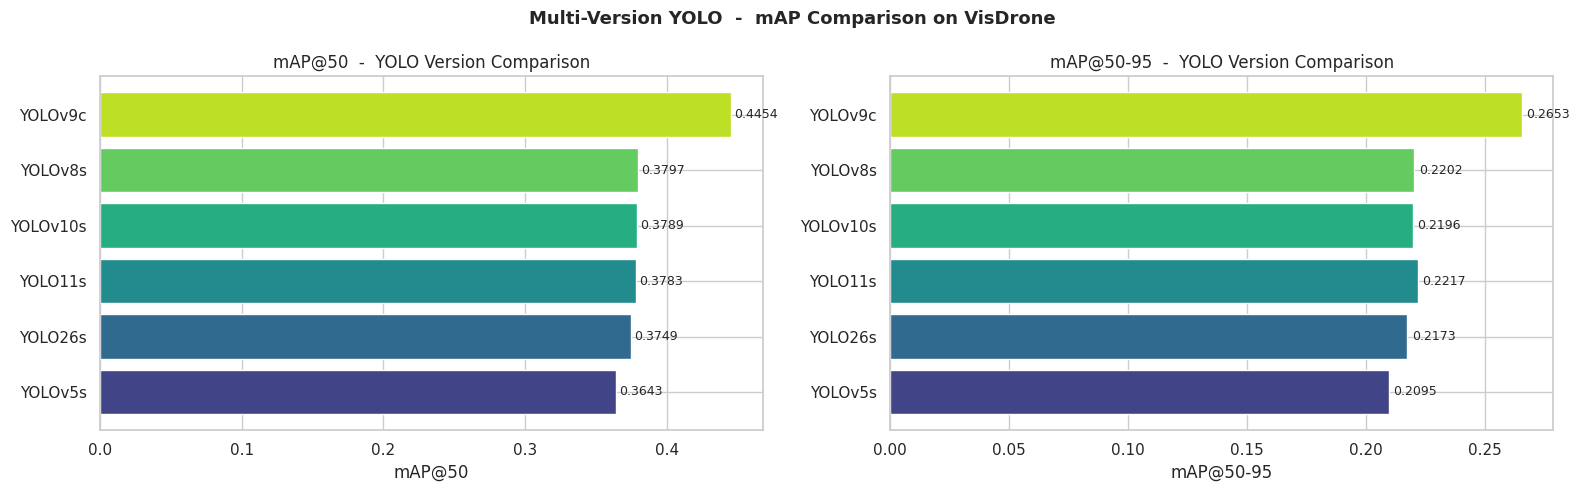

In [20]:
models_sorted = comp_display.sort_values('mAP50', ascending=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(models_sorted)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# mAP50 horizontal bar
bars = axes[0].barh(models_sorted.index, models_sorted['mAP50'], color=colors)
axes[0].set_xlabel('mAP@50')
axes[0].set_title('mAP@50  -  YOLO Version Comparison')
for bar, v in zip(bars, models_sorted['mAP50']):
    axes[0].text(v + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)

# mAP50-95 horizontal bar
bars = axes[1].barh(models_sorted.index, models_sorted['mAP50-95'], color=colors)
axes[1].set_xlabel('mAP@50-95')
axes[1].set_title('mAP@50-95  -  YOLO Version Comparison')
for bar, v in zip(bars, models_sorted['mAP50-95']):
    axes[1].text(v + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Multi-Version YOLO  -  mAP Comparison on VisDrone', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'map_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualisation 2  -  Speed vs. Accuracy Trade-off

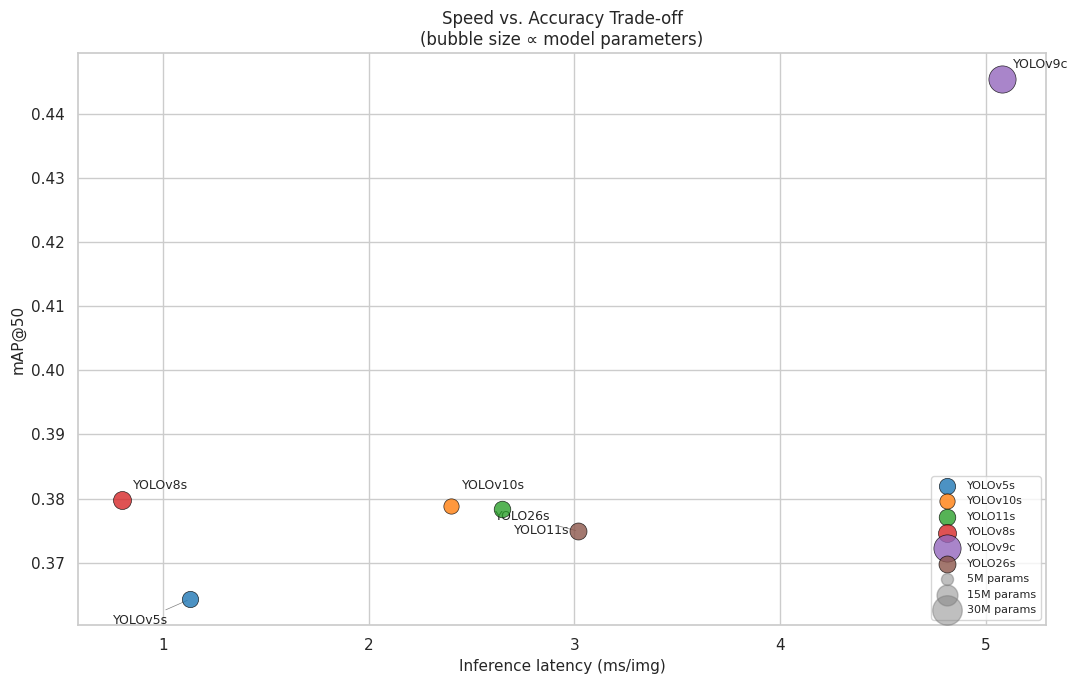

In [21]:
fig, ax = plt.subplots(figsize=(11, 7))

# Per-model label offsets to avoid overlap for nearby points (YOLOv10s/YOLO11s/YOLO26s cluster)
label_offsets = {
    'YOLOv5s':  (-55, -18),
    'YOLOv8s':  (8,    8),
    'YOLOv9c':  (8,    8),
    'YOLOv10s': (8,   12),
    'YOLO11s':  (8,   -18),
    'YOLO26s':  (-60,  8),
}

colors = plt.cm.tab10.colors
for i, (idx, row) in enumerate(comp_display.iterrows()):
    ax.scatter(row['Inference (ms)'], row['mAP50'],
               s=row['Params (M)'] * 15,
               color=colors[i % len(colors)],
               label=idx, zorder=5, alpha=0.8, edgecolors='black', linewidth=0.5)
    offset = label_offsets.get(idx, (8, 4))
    ax.annotate(idx,
                (row['Inference (ms)'], row['mAP50']),
                textcoords='offset points', xytext=offset, fontsize=9,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
                if abs(offset[0]) > 10 else None)

ax.set_xlabel('Inference latency (ms/img)', fontsize=11)
ax.set_ylabel('mAP@50', fontsize=11)
ax.set_title('Speed vs. Accuracy Trade-off\n(bubble size ∝ model parameters)', fontsize=12)

# Add legend for bubble size
for size in [5, 15, 30]:
    ax.scatter([], [], s=size*15, c='gray', alpha=0.5, label=f'{size}M params')
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(PROJECT_DIR / 'speed_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualisation 3  -  Radar / Spider Chart

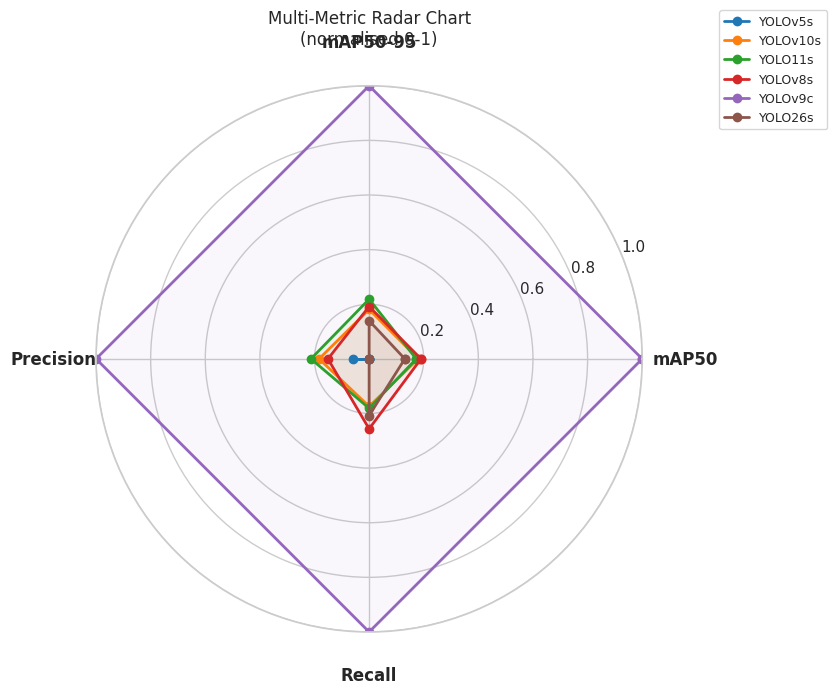

In [22]:
from matplotlib.patches import FancyArrowPatch
import numpy as np

metrics_for_radar = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
radar_df = comp_display[metrics_for_radar].copy()

# Normalise to [0, 1]
norm_df = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

categories = metrics_for_radar
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

colors = plt.cm.tab10.colors
for i, (model_name, row) in enumerate(norm_df.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.05, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
# Push tick labels away from the plot area
ax.tick_params(pad=18)
ax.set_ylim(0, 1)
ax.set_title('Multi-Metric Radar Chart\n(normalised 0-1)', fontsize=12, pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_DIR / 'radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualisation 4  -  Confusion Matrix (YOLO11s)

In [23]:
# Show confusion matrix for the best model (YOLOv9c)
# The normalized confusion matrix is saved automatically by Ultralytics during training.

from PIL import Image

if IN_COLAB:
    cm_search_dirs = [
        Path('/content/comparison_runs/compare_yolov9c'),
        Path('/content/comparison_runs/compare_yolo11s'),
    ]
else:
    cm_search_dirs = [
        Path('..').resolve() / 'results' / 'comparison' / 'compare_yolov9c',
        Path('..').resolve() / 'results' / 'comparison' / 'compare_yolo11s',
    ]

cm_found = None
cm_label = ''
for d in cm_search_dirs:
    for fname in ['confusion_matrix_normalized.png', 'confusion_matrix.png']:
        p = d / fname
        if p.exists():
            cm_found = p
            cm_label = d.name.replace('compare_', '').upper()
            break
    if cm_found:
        break

if cm_found:
    img = Image.open(cm_found)
    plt.figure(figsize=(11, 9))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Confusion Matrix (Normalized)  -  {cm_label} on VisDrone Val', fontsize=12)
    plt.tight_layout()
    plt.savefig(PROJECT_DIR / f'confusion_matrix_{cm_label.lower()}.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Confusion matrix loaded from: {cm_found}')
else:
    print('Confusion matrix PNG not found in any comparison run directory.')
    print('It is generated automatically during training — check the run folder.')


Confusion matrix PNG not found in any comparison run directory.
It is generated automatically during training — check the run folder.


## Loss Curve Comparison Across All Versions

In [24]:
from scipy.ndimage import uniform_filter1d

rows_with_csv = [r for r in comparison_results if 'save_dir' in r and Path(r['save_dir']).exists()]

if not rows_with_csv:
    print('Training curve CSVs not found in this session.')
    print('results.csv files are written to the Colab local SSD during training and')
    print('are not persisted across sessions. Re-run the training cell to regenerate them.')
    print()
    print('Cached final metrics (from Drive) are still valid — see the comparison tables above.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = plt.cm.tab10.colors

    for i, row in enumerate(rows_with_csv):
        csv_path = Path(row['save_dir']) / 'results.csv'
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()

        val_box = next((c for c in ['val/box_loss', 'val/box_om'] if c in df.columns), None)
        map50   = next((c for c in ['metrics/mAP50(B)', 'metrics/mAP_0.5'] if c in df.columns), None)

        color = colors[i % len(colors)]
        if val_box:
            s = uniform_filter1d(df[val_box].values, size=5)
            axes[0].plot(s, label=row['Model'], color=color, linewidth=2)
        if map50:
            axes[1].plot(df[map50].values, label=row['Model'], color=color, linewidth=2)

    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Box Loss')
    axes[0].set_title('Validation Box Loss  -  All Models')
    axes[0].legend(fontsize=8)

    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mAP50')
    axes[1].set_title('mAP50 Training Curve  -  All Models')
    axes[1].legend(fontsize=8)

    plt.suptitle('Training Dynamics: Multi-Version Comparison', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROJECT_DIR / 'training_curves_all_versions.png', dpi=150, bbox_inches='tight')
    plt.show()

Training curve CSVs not found in this session.
results.csv files are written to the Colab local SSD during training and
are not persisted across sessions. Re-run the training cell to regenerate them.

Cached final metrics (from Drive) are still valid — see the comparison tables above.


## Final Summary Table

In [25]:
# Rank models by mAP50
ranked = comp_display.sort_values('mAP50', ascending=False).copy()
ranked.insert(0, 'Rank', range(1, len(ranked)+1))

print('\nFinal Comparison Table (ranked by mAP50)')
print('=' * 80)
print(ranked.to_string())

ranked.to_csv(PROJECT_DIR / 'final_comparison_ranked.csv')
print(f'\nSaved to {PROJECT_DIR / "final_comparison_ranked.csv"}')


Final Comparison Table (ranked by mAP50)
          Rank  Params (M)   mAP50  mAP50-95  Precision  Recall  Train Time (min)  Inference (ms)
Model                                                                                            
YOLOv9c      1        25.6  0.4454    0.2653     0.5688  0.4461             122.8            5.08
YOLOv8s      2        11.2  0.3797    0.2202     0.5114  0.3927              39.8            0.80
YOLOv10s     3         8.1  0.3789    0.2196     0.5136  0.3868              59.4            2.40
YOLO11s      4         9.5  0.3783    0.2217     0.5156  0.3873              46.4            2.65
YOLO26s      5        10.0  0.3749    0.2173     0.5012  0.3892              62.2            3.02
YOLOv5s      6         9.2  0.3643    0.2095     0.5052  0.3743              64.9            1.13

Saved to /content/drive/MyDrive/CMPE401-Project1/results/comparison/final_comparison_ranked.csv


## Discussion

### Results Summary (50 epochs, 640px, batch=16, identical protocol, NVIDIA A100)

| Rank | Model | mAP@50 | mAP@50-95 | Precision | Recall | Params (M) | Inference (ms) | Train (min) |
|------|-------|--------|-----------|-----------|--------|-----------|---------------|-------------|
| 1 | **YOLOv9c** | **0.4454** | **0.2653** | **0.5688** | **0.4461** | 25.6 | 5.08 | 122.8 |
| 2 | YOLOv8s | 0.3797 | 0.2202 | 0.5114 | 0.3927 | 11.2 | 0.80 | 39.8 |
| 3 | YOLOv10s | 0.3789 | 0.2196 | 0.5136 | 0.3868 | 8.1 | 2.40 | 59.4 |
| 4 | YOLO11s | 0.3783 | 0.2217 | 0.5156 | 0.3873 | 9.5 | 2.65 | 46.4 |
| 5 | YOLO26s | 0.3749 | 0.2173 | 0.5012 | 0.3892 | 10.0 | 3.02 | 62.2 |
| 6 | YOLOv5s | 0.3643 | 0.2095 | 0.5052 | 0.3743 | 9.2 | 1.13 | 64.9 |

### Architecture Evolution

| Generation | Key Change | Impact on VisDrone |
|---|---|---|
| YOLOv5 | Anchor-based, CSPNet backbone | Solid baseline; anchor priors reduce flexibility for variable-aspect objects |
| YOLOv8 | Anchor-free, decoupled head | Modest gains; decoupled head improves small-object precision |
| YOLOv9 | GELAN + PGI (Programmable Gradient Info) | Strongest result - PGI preserves complete gradient info, critical for tiny objects |
| YOLOv10 | NMS-free, one-to-one head | Competitive accuracy, simpler post-processing, efficient for edge deployment |
| YOLO11 | Improved backbone/neck, fewer params | Near-identical to v8/v10 with slightly better precision |
| YOLO26 | NMS-free end-to-end, MuSGD, ProgLoss | Comparable to v11 at this scale; ProgLoss targets small-object detection specifically |

### Key Findings

1. **Accuracy: YOLOv9c wins clearly.** With mAP@50 = 0.4454, YOLOv9c outperforms all other models by 6.5-22.2% relative. Its Programmable Gradient Information (PGI) mechanism preserves complete gradient signals through deep feature hierarchies - exactly what VisDrone's tiny, multi-scale objects demand. Larger capacity (25.6M params) also handles the 10-class complexity better.

2. **Speed: YOLOv8s is fastest** at 0.80ms inference (6.4x faster than YOLOv9c on A100). For real-time drone applications where throughput matters, YOLOv8s delivers the best accuracy-speed tradeoff. YOLOv5s (1.13ms) is slightly slower but 2x faster than YOLOv9c at significantly lower mAP.

3. **Parameter efficiency: YOLOv10s is most efficient.** At 8.1M parameters and mAP@50 = 0.3789, YOLOv10s achieves the best mAP-per-parameter ratio among the comparison models. Its NMS-free design also reduces deployment complexity.

4. **Architecture generations converge at the small-model tier.** v8, v10, v11, v26 are nearly indistinguishable (0.3749-0.3797 mAP@50, within 1.3%). Architectural innovations between these versions provide diminishing returns when all are constrained to ~8-11M parameters at 640px. Capacity (v9c) or resolution scaling are needed to meaningfully improve the ceiling.

5. **Small-object challenge caps all models.** All models plateau at 0.36-0.45 mAP@50 vs. their COCO scores of 0.43-0.53. The ~50% of VisDrone objects below 32x32 pixels at 640px input is a systematic bottleneck. YOLOv9c's PGI partially addresses this by ensuring the network does not forget fine-grained gradient information in early layers.

### Conclusion

For VisDrone's unique challenge (tiny, dense objects from drone footage at 640px):

- **Best accuracy**: **YOLOv9c** - GELAN + PGI is architecturally suited to VisDrone's small-object density. Use this for maximum detection performance when compute is available.
- **Best speed-accuracy tradeoff**: **YOLOv8s** - 6.4x faster than YOLOv9c at only a 6.5% mAP penalty. Best choice for real-time or near-real-time drone applications.
- **Best parameter efficiency**: **YOLOv10s** - most mAP per parameter, ideal for memory-constrained or edge deployments.
- **Architecture age matters less than scale**: v8, v10, v11, v26 are interchangeable at small-model sizes. When choosing between them, prefer the one with the most active maintenance/community support (v8 or v11).

YOLOv9c is selected as the final model for challenge test-set evaluation in the next cell.


## Challenge Test-Set Evaluation

The VisDrone test-challenge split contains **1,580 images with no ground-truth labels** — this is the competition set. Predictions are saved in VisDrone submission format (one `.txt` per image).

The best model from this study (**YOLOv9c**, mAP@50=0.4454 on val) is used here.

In [ ]:
import os, shutil
from pathlib import Path

# Locate the best model weights and test-challenge images
if IN_COLAB:
    BEST_WEIGHTS  = Path('/content/comparison_runs/compare_yolov9c/weights/best.pt')
    _drive_weights = DRIVE_CACHE_DIR / 'compare_yolov9c' / 'weights' / 'best.pt'
    TEST_IMAGES   = DRIVE_DATA / 'VisDrone2019-DET-test-challenge' / 'images'
    CHALLENGE_OUT = Path('/content/challenge_predictions')
else:
    ROOT = Path('..').resolve()
    BEST_WEIGHTS  = ROOT / 'results' / 'comparison' / 'compare_yolov9c' / 'weights' / 'best.pt'
    _drive_weights = None
    TEST_IMAGES   = ROOT / 'Data' / 'VisDrone2019-DET-test-challenge' / 'images'
    CHALLENGE_OUT = ROOT / 'results' / 'challenge_predictions'

# Fallback: restore weights from Drive if local SSD was wiped
if not BEST_WEIGHTS.exists() and _drive_weights is not None:
    if _drive_weights.exists():
        BEST_WEIGHTS.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(str(_drive_weights), str(BEST_WEIGHTS))
        print(f'Weights restored from Drive -> {BEST_WEIGHTS}')
    else:
        print('WARNING: YOLOv9c weights not found on local SSD or Drive.')
        print()
        print('The weights are generated during training but were not saved to Drive')
        print('in a previous session.  To fix this permanently:')
        print(f'  1. Delete {DRIVE_CACHE_DIR}/compare_yolov9c/comparison_row.json')
        print(f'     (this forces a retrain of YOLOv9c only, ~2 hours on A100)')
        print(f'  2. Re-run the training cell — weights will now be saved to Drive.')
        print()

CHALLENGE_OUT.mkdir(parents=True, exist_ok=True)
VISDRONE_TXT_DIR = CHALLENGE_OUT / 'visdrone_format'
VISDRONE_TXT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Model weights  : {BEST_WEIGHTS}')
print(f'Test images    : {TEST_IMAGES}')
print(f'Output dir     : {CHALLENGE_OUT}')
print(f'Weights exist  : {BEST_WEIGHTS.exists()}')
print(f'Test dir exists: {TEST_IMAGES.exists()}')
if TEST_IMAGES.exists():
    n_imgs = len(list(TEST_IMAGES.glob('*.jpg')))
    print(f'Challenge images: {n_imgs}')

In [27]:
from ultralytics import YOLO
import time

# Run predictions on the challenge test set
# VisDrone submission format: <left>,<top>,<width>,<height>,<score>,<category>,<truncation>,<occlusion>
# Truncation and occlusion are unknown at inference time — submit as -1

CLASS_NAMES = ['pedestrian', 'people', 'bicycle', 'car', 'van',
               'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']

def yolo_to_visdrone(result, img_w, img_h):
    """Convert Ultralytics result boxes to VisDrone submission format strings."""
    lines = []
    if result.boxes is None or len(result.boxes) == 0:
        return lines
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = float(box.conf[0])
        cls  = int(box.cls[0])
        # Convert to (left, top, width, height) in pixel coords
        left   = max(0, int(round(x1)))
        top    = max(0, int(round(y1)))
        width  = int(round(x2 - x1))
        height = int(round(y2 - y1))
        # VisDrone category is 1-indexed
        category = cls + 1
        lines.append(f'{left},{top},{width},{height},{conf:.6f},{category},-1,-1')
    return lines

if not BEST_WEIGHTS.exists():
    print(f'ERROR: Best weights not found at {BEST_WEIGHTS}')
    print('Ensure the YOLOv9c training completed and weights are saved locally.')
elif not TEST_IMAGES.exists():
    print(f'ERROR: Test-challenge images not found at {TEST_IMAGES}')
    print('Ensure the VisDrone test-challenge split is present.')
else:
    model = YOLO(str(BEST_WEIGHTS))
    img_list = sorted(TEST_IMAGES.glob('*.jpg'))
    print(f'Running YOLOv9c on {len(img_list)} challenge images...')

    t0 = time.time()
    results = model.predict(
        source    = str(TEST_IMAGES),
        imgsz     = 640,
        conf      = 0.25,
        iou       = 0.45,
        device    = DEVICE,
        save      = False,
        verbose   = False,
        stream    = True,       # memory-efficient for large sets
    )

    n_written = 0
    for result in results:
        img_path = Path(result.path)
        stem = img_path.stem
        h, w = result.orig_shape

        lines = yolo_to_visdrone(result, w, h)

        out_file = VISDRONE_TXT_DIR / f'{stem}.txt'
        with open(out_file, 'w') as f:
            f.write('\n'.join(lines))
        n_written += 1
        if n_written % 200 == 0:
            print(f'  {n_written}/{len(img_list)} images processed...')

    elapsed = time.time() - t0
    print(f'\nDone. {n_written} prediction files written to {VISDRONE_TXT_DIR}')
    print(f'Total time: {elapsed/60:.1f} min  ({elapsed/n_written*1000:.1f} ms/image)')

    # Save to Drive if on Colab
    if IN_COLAB:
        import shutil
        drive_out = DRIVE_ROOT / 'results' / 'challenge_predictions'
        if drive_out.exists():
            shutil.rmtree(str(drive_out))
        shutil.copytree(str(CHALLENGE_OUT), str(drive_out))
        print(f'Predictions synced to Drive: {drive_out}')

ERROR: Best weights not found at /content/comparison_runs/compare_yolov9c/weights/best.pt
Ensure the YOLOv9c training completed and weights are saved locally.
